# Crawling & Analisis Data Polutan Udara di Kabupaten Bangkalan

Nama :Moh Rafie Nazar J

NIM :240411100003

Mata Kuliah : Pengantar Sains Data (PSD)

## Latar Belakang

Kabupaten Bangkalan merupakan salah satu kabupaten di Provinsi Jawa Timur yang memiliki karakteristik wilayah yang beragam, meliputi sektor pertanian (padi, jagung, dan tambak ikan), peternakan, perikanan, serta aktivitas industri dan perdagangan yang terus berkembang. Beberapa industri yang beroperasi di Bangkalan antara lain industri pengolahan hasil perikanan, industri makanan dan minuman, industri kayu, serta pembangkit listrik. Selain itu, wilayah Bangkalan dilalui jalur transportasi utama Pantai Utara (Pantura) Jawa yang memiliki intensitas lalu lintas kendaraan berat (truk dan bus) yang cukup tinggi. Sektor pertanian yang luas, khususnya lahan sawah, juga menjadi sumber emisi metana (CH4) yang signifikan, sementara aktivitas pembakaran lahan dan sampah berkontribusi pada peningkatan konsentrasi CO dan HCHO di atmosfer. Oleh karena itu, pemantauan konsentrasi polutan udara seperti Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Formaldehida (HCHO), Ozon troposferik (O3), Sulfur Dioksida (SO2), dan Metana (CH4) menjadi penting untuk memahami kondisi kualitas udara di wilayah Kabupaten Bangkalan dari waktu ke waktu.


## 1. Business Understanding

### a. Tujuan

Tugas ini bertujuan untuk mengetahui sumber-sumber polutan serta kondisi/kualitas udara di wilayah Kabupaten Bangkalan, melalui proses crawling data satelit untuk enam jenis polutan (CO, NO2, HCHO, O3, SO2, CH4), eksplorasi data (data understanding), serta visualisasi data time series selama kurun waktu minimal satu tahun sebelum 31 Agustus 2026.

### b. Manfaat

Manfaat yang diharapkan dari tugas ini antara lain:

1. Memberikan gambaran mengenai pola dan tren konsentrasi masing-masing polutan di wilayah Bangkalan sepanjang waktu.
2. Membantu mengidentifikasi kemungkinan sumber dominan tiap polutan berdasarkan karakteristik wilayah Bangkalan (pertanian, peternakan, perikanan, transportasi, dan industri).
3. Menjadi bahan evaluasi awal terkait kondisi kualitas udara di wilayah tersebut.
4. Menjadi dasar bagi analisis lanjutan (preprocessing dan pemodelan) pada tahap berikutnya.
5. Melatih kemampuan pengambilan data dari sumber data satelit (remote sensing) serta praktik data understanding untuk data time series lingkungan.

### c. Kemungkinan Sumber Masing-Masing Polutan

| Polutan | Deskripsi Singkat | Kemungkinan Sumber di Bangkalan |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas hasil pembakaran tidak sempurna bahan bakar fosil | Emisi kendaraan bermotor di jalur Pantura, pembakaran lahan pertanian/sampah, aktivitas industri pengolahan, kebakaran lahan |
| **NO2** (Nitrogen Dioksida) | Gas pencemar hasil pembakaran suhu tinggi | Emisi kendaraan berat di jalur Pantura, aktivitas industri dan pembangkit listrik, pembakaran bahan bakar fosil |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran lahan pertanian/biomassa, industri kayu dan pengolahan, emisi kendaraan, oksidasi VOC alami dari vegetasi pertanian yang luas |
| **O3** (Ozon troposferik) | Polutan sekunder, terbentuk dari reaksi fotokimia | Reaksi fotokimia antara NOx dan VOC dengan bantuan sinar matahari, terkait emisi kendaraan Pantura dan lahan pertanian yang luas |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung sulfur | Pembangkit listrik, industri pengolahan, serta pembakaran bahan bakar fosil pada kendaraan dan aktivitas industri di Bangkalan |
| **CH4** (Metana) | Gas rumah kaca, salah satu VOC utama | Lahan persawahan yang sangat luas (Bangkalan adalah penghasil padi terbesar Jawa Timur), peternakan sapi dan unggas, tempat pembuangan akhir (TPA) sampah, serta tambak ikan |

### d. Deskripsi Data

Data yang digunakan pada tugas ini bersumber dari citra satelit **Sentinel-5P TROPOMI** (Tropospheric Monitoring Instrument) yang dikelola oleh European Space Agency (ESA) di bawah program Copernicus, diakses melalui platform **Copernicus Data Space Ecosystem** menggunakan pustaka `openeo` pada Python dengan koleksi data `SENTINEL_5P_L2`.

Setiap band (CO, NO2, HCHO, O3, SO2, CH4) merepresentasikan nilai kolom vertikal (*total column density*) gas tersebut di atmosfer, pada satuan **mol/m²**, dengan resolusi spasial berkisar antara 5.5×3.5 km hingga 7×7 km tergantung jenis produknya, dan resolusi temporal harian (satu kali lintasan per hari untuk wilayah tertentu, dengan kemungkinan data kosong pada beberapa hari akibat tutupan awan).

Perlu dicatat bahwa pada implementasi openEO/Sentinel Hub API saat ini, satu permintaan data (`load_collection`) hanya dapat memuat **satu band/jenis polutan** untuk koleksi Sentinel-5P L2 — sehingga proses crawling keenam polutan pada tugas ini dilakukan secara terpisah (loop) satu per satu, dan hasilnya diunduh sebagai berkas NetCDF (`.nc`) terpisah untuk masing-masing polutan.


## 2. Penentuan Wilayah Kajian (Area of Interest) Menggunakan GeoJSON.io

Wilayah kajian ditentukan menggunakan berkas **GeoJSON** berbentuk polygon yang mencakup wilayah Kabupaten Bangkalan (dan sekitarnya), digambar melalui [geojson.io](https://geojson.io) kemudian disimpan sebagai berkas `.geojson` dan dibaca kembali menggunakan Python untuk membatasi wilayah pengambilan data pada tahap crawling.

In [ ]:
import json

# GeoJSON wilayah kajian (Kabupaten Bangkalan)
# ================================================================
# Polygon dibuat berdasarkan bounding box wilayah Bangkalan.
# Format koordinat: [longitude, latitude].
# Jika dosen meminta batas administrasi yang lebih presisi,
# polygon ini dapat diganti dengan GeoJSON hasil gambar di geojson.io.
# ================================================================

aoi_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [112.674103, -7.217445],
                    [113.147072, -7.217445],
                    [113.147072, -6.878810],
                    [112.674103, -6.878810],
                    [112.674103, -7.217445]
                ]]
            }
        }
    ]
}

with open("aoi_bangkalan.geojson", "w") as f:
    json.dump(aoi_geojson, f, indent=2)

print("Berkas aoi_bangkalan.geojson berhasil disimpan.")


Berkas aoi_bangkalan.geojson berhasil disimpan.


In [ ]:
with open("aoi_bangkalan.geojson", "r") as f:
    aoi_geojson = json.load(f)

polygon_coords = aoi_geojson["features"][0]["geometry"]["coordinates"][0]
lons = [c[0] for c in polygon_coords]
lats = [c[1] for c in polygon_coords]

bbox = {
    "west": min(lons),
    "south": min(lats),
    "east": max(lons),
    "north": max(lats)
}

print("Bounding box wilayah kajian (Bangkalan):")
print(bbox)

Bounding box wilayah kajian (Bangkalan):
{'west': 112.674103, 'south': -7.217445, 'east': 113.147072, 'north': -6.87881}


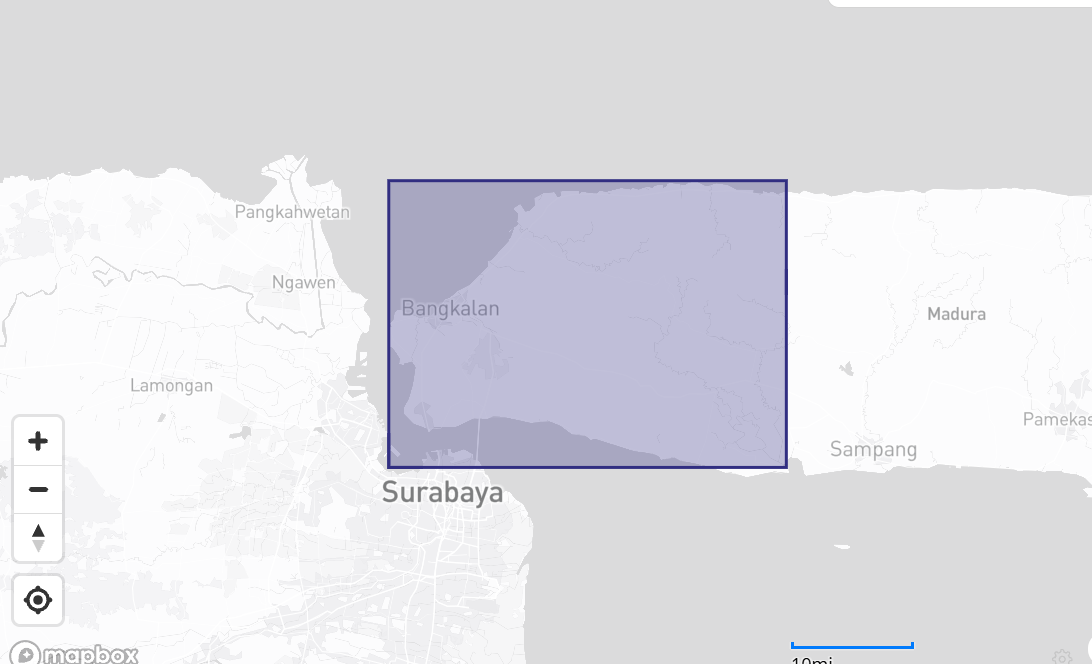

## 3. Data Collection (Crawling Data)

### a. Instalasi Library dan Koneksi ke Copernicus Data Space Ecosystem

In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=EPTG-OEGR 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### b. Crawling Enam Polutan (CO, NO2, HCHO, O3, SO2, CH4)

Rentang waktu pengamatan ditentukan minimal satu tahun hingga tanggal 31 Agustus 2026, sesuai ketentuan tugas. Karena satu permintaan hanya dapat memuat satu band, proses crawling dilakukan melalui perulangan (`loop`) untuk setiap polutan, dan masing-masing hasil diunduh sebagai berkas NetCDF terpisah.

**Catatan:** apabila notebook ini dijalankan sebelum tanggal 31 Agustus 2026, data yang tersedia hanya akan mencakup tanggal terbaru yang sudah direkam satelit pada saat crawling dijalankan. Notebook perlu dijalankan ulang mendekati/sesudah tanggal tersebut agar rentang data benar-benar lengkap.

In [ ]:
pollutants = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

start_date = "2025-08-29"
end_date = "2026-08-31"

for pol in pollutants:
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=bbox,
        bands=[pol],
    )
    cube_daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    cube_daily.execute_batch(title=f"{pol} in Bangkalan", outputfile=f"{pol}_Bangkalan.nc")
    print(f"Selesai mengunduh data {pol} -> {pol}_Bangkalan.nc")

0:00:00 Job 'j-26090700170642c98522b5e700f8bb2c': send 'start'
0:00:04 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:00:09 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:00:16 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:00:24 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:00:34 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:00:47 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:01:02 Job 'j-26090700170642c98522b5e700f8bb2c': queued (progress 0%)
0:01:22 Job 'j-26090700170642c98522b5e700f8bb2c': running (progress N/A)
0:01:46 Job 'j-26090700170642c98522b5e700f8bb2c': running (progress N/A)
0:02:16 Job 'j-26090700170642c98522b5e700f8bb2c': running (progress N/A)
0:02:54 Job 'j-26090700170642c98522b5e700f8bb2c': running (progress N/A)
0:03:41 Job 'j-26090700170642c98522b5e700f8bb2c': finished (progress 100%)
Selesai mengunduh data CO -> CO_Bangkalan.nc
0:00:00 Job 'j-2609070020574

Proses pengambilan data dapat dipantau pada halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2, yang menampilkan status job serta dataset yang sedang diproses untuk masing-masing polutan.

## 4. Data Understanding

### a. Membaca Seluruh Berkas NetCDF dan Menyimpan ke CSV

Setiap berkas NetCDF hasil crawling dibaca, dihitung rata-rata nilai per hari untuk seluruh grid dalam wilayah kajian, kemudian disimpan ke dalam berkas CSV terpisah untuk masing-masing polutan.

In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.8 MB/s eta 0:00:00


In [ ]:
import netCDF4
import numpy as np
import pandas as pd

def read_daily_mean(band_name, filename):
    ds = netCDF4.Dataset(filename)

    values = ds.variables[band_name][:]
    time = ds.variables["t"][:]
    time_units = ds.variables["t"].units

    dates = netCDF4.num2date(
        time,
        units=time_units
    )

    daily_dates = [
        d.strftime("%Y-%m-%d")
        for d in dates
    ]

    daily_mean = []

    for i in range(len(values)):

        # Ambil satu hari
        data_harian = values[i]

        # Hitung mean dengan mengabaikan masked value
        mean_value = np.ma.mean(data_harian)

        # Ubah masked menjadi NaN
        if np.ma.is_masked(mean_value):
            mean_value = np.nan
        else:
            mean_value = float(mean_value)

        daily_mean.append(mean_value)

    df = pd.DataFrame({
        "date": daily_dates,
        band_name: daily_mean
    })

    df["date"] = pd.to_datetime(df["date"])

    # Pastikan benar-benar numeric
    df[band_name] = pd.to_numeric(
        df[band_name],
        errors="coerce"
    )

    return df

# Membaca semua data polutan
dataframes = {}

for pol in pollutants:
    df_pol = read_daily_mean(
        pol,
        f"{pol}_Bangkalan.nc"
    )

    dataframes[pol] = df_pol

    print(
        f"{pol}: {df_pol.shape[0]} baris data berhasil dibaca"
    )


# ==========================================
# GABUNGKAN LANGSUNG BERDASARKAN TANGGAL
# ==========================================

merged_df = dataframes[pollutants[0]][["date"]].copy()

for pol in pollutants:
    merged_df = merged_df.merge(
        dataframes[pol][["date", pol]],
        on="date",
        how="outer"
    )

# Urutkan berdasarkan tanggal
merged_df = merged_df.sort_values(
    "date"
).reset_index(drop=True)


# ==========================================
# SIMPAN HANYA SATU CSV
# ==========================================

merged_df.to_csv(
    "all_polutan_Bangkalan_timeseries.csv",
    index=False
)

print("\nData berhasil disimpan!")
print("Nama file: all_polutan_Bangkalan_timeseries.csv")
print("Jumlah baris:", len(merged_df))
print("Kolom:", merged_df.columns.tolist())

display(merged_df.head())

CO: 367 baris data berhasil dibaca
NO2: 365 baris data berhasil dibaca
HCHO: 353 baris data berhasil dibaca
O3: 363 baris data berhasil dibaca
SO2: 353 baris data berhasil dibaca
CH4: 217 baris data berhasil dibaca

Data berhasil disimpan!
Nama file: all_polutan_Bangkalan_timeseries.csv
Jumlah baris: 367
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-29,0.026103,0.000026,0.000143,0.113214,8.791764e-05,1843.975260
1,2025-08-30,0.025363,0.000020,0.000077,0.115004,8.026050e-07,NaN
2,2025-08-31,0.025741,0.000013,0.000124,0.115688,6.201892e-06,NaN
3,2025-09-01,0.026722,0.000017,0.000082,0.115264,3.424412e-05,NaN
4,2025-09-02,0.024523,0.000012,0.000047,0.113861,-2.543385e-05,1837.764526


### b. Mengecek Struktur dan Isi Data

Untuk masing-masing polutan, diperiksa struktur data (tipe kolom, jumlah baris) serta beberapa baris pertama untuk memastikan hasil crawling sesuai yang diharapkan.

In [ ]:
print("=== Struktur Data Polutan Bangkalan ===")
merged_df.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", merged_df.shape[0])
print("Jumlah kolom :", merged_df.shape[1])

print("\n=== Nama Kolom ===")
print(merged_df.columns.tolist())

print("\n=== 5 Data Pertama ===")
display(merged_df.head())

print("\n=== 5 Data Terakhir ===")
display(merged_df.tail())

=== Struktur Data Polutan Bangkalan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    367 non-null    datetime64[ns]
 1   CO      279 non-null    float64       
 2   NO2     293 non-null    float64       
 3   HCHO    323 non-null    float64       
 4   O3      363 non-null    float64       
 5   SO2     314 non-null    float64       
 6   CH4     85 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.2 KB

=== Ukuran Dataset ===
Jumlah baris : 367
Jumlah kolom : 7

=== Nama Kolom ===
['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']

=== 5 Data Pertama ===


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-29,0.026103,0.000026,0.000143,0.113214,8.791764e-05,1843.975260
1,2025-08-30,0.025363,0.000020,0.000077,0.115004,8.026050e-07,NaN
2,2025-08-31,0.025741,0.000013,0.000124,0.115688,6.201892e-06,NaN
3,2025-09-01,0.026722,0.000017,0.000082,0.115264,3.424412e-05,NaN
4,2025-09-02,0.024523,0.000012,0.000047,0.113861,-2.543385e-05,1837.764526



=== 5 Data Terakhir ===


,date,CO,NO2,HCHO,O3,SO2,CH4
362,2026-08-26,0.030068,0.000023,0.000172,0.119329,0.000160,1895.771369
363,2026-08-27,0.029916,0.000029,0.000146,0.117706,0.000044,1892.712891
364,2026-08-28,0.036505,0.000025,0.000180,0.117117,-0.000030,1868.974918
365,2026-08-29,0.037011,0.000018,0.000115,0.116052,0.000041,NaN
366,2026-08-30,0.034216,0.000019,0.000088,0.114673,-0.000062,1910.137044


### c. Mengecek Missing Value

Missing value pada data Sentinel-5P umumnya terjadi akibat tutupan awan (*cloud cover*) yang menghalangi pengukuran satelit, sehingga sensor tidak mencatat nilai valid pada tanggal tertentu.

In [ ]:
print(f"{'Polutan':<8}{'Jumlah Baris':<15}{'Missing Value':<15}{'Persentase':<10}")

for pol in pollutants:
    n_total = len(merged_df)
    n_missing = merged_df[pol].isna().sum()
    pct = n_missing / n_total * 100 if n_total > 0 else 0
    print(f"{pol:<8}{n_total:<15}{n_missing:<15}{pct:.2f}%")

Polutan Jumlah Baris   Missing Value  Persentase
CO      367            88             23.98%
NO2     367            74             20.16%
HCHO    367            44             11.99%
O3      367            4              1.09%
SO2     367            53             14.44%
CH4     367            282            76.84%


### d. Mengecek Data Aneh / Outlier

Statistik deskriptif dan deteksi outlier menggunakan metode *Interquartile Range* (IQR) digunakan untuk mengidentifikasi nilai yang berada jauh di luar sebaran normal data, termasuk mengecek kewajaran nilai (apakah terdapat nilai negatif ekstrem yang tidak wajar secara fisis).

In [ ]:
summary_rows = []

for pol in pollutants:

    # Ambil kolom polutan dari dataset utama
    series = merged_df[pol].dropna()

    # Kuartil
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah outlier
    n_outliers = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    summary_rows.append({
        "Polutan": pol,
        "Min": series.min(),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std": series.std(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier IQR": n_outliers
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Polutan,Min,Max,Mean,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier IQR
0,CO,0.020487,0.043208,0.028658,0.002864,0.026678,0.030174,0.003496,0.021433,0.035419,7
1,NO2,0.000004,0.000109,0.000025,0.000011,0.000019,0.000030,0.000011,0.000003,0.000046,8
2,HCHO,-0.000181,0.000622,0.000164,0.000084,0.000121,0.000197,0.000075,0.000008,0.000310,23
3,O3,0.110552,0.122840,0.115805,0.002286,0.114112,0.117300,0.003188,0.109330,0.122082,2
4,SO2,-0.000862,0.000381,0.000037,0.000125,-0.000014,0.000097,0.000111,-0.000180,0.000264,25
5,CH4,1674.215576,1938.674194,1868.118059,40.573524,1846.357422,1896.616211,50.258789,1770.969238,1972.004395,2


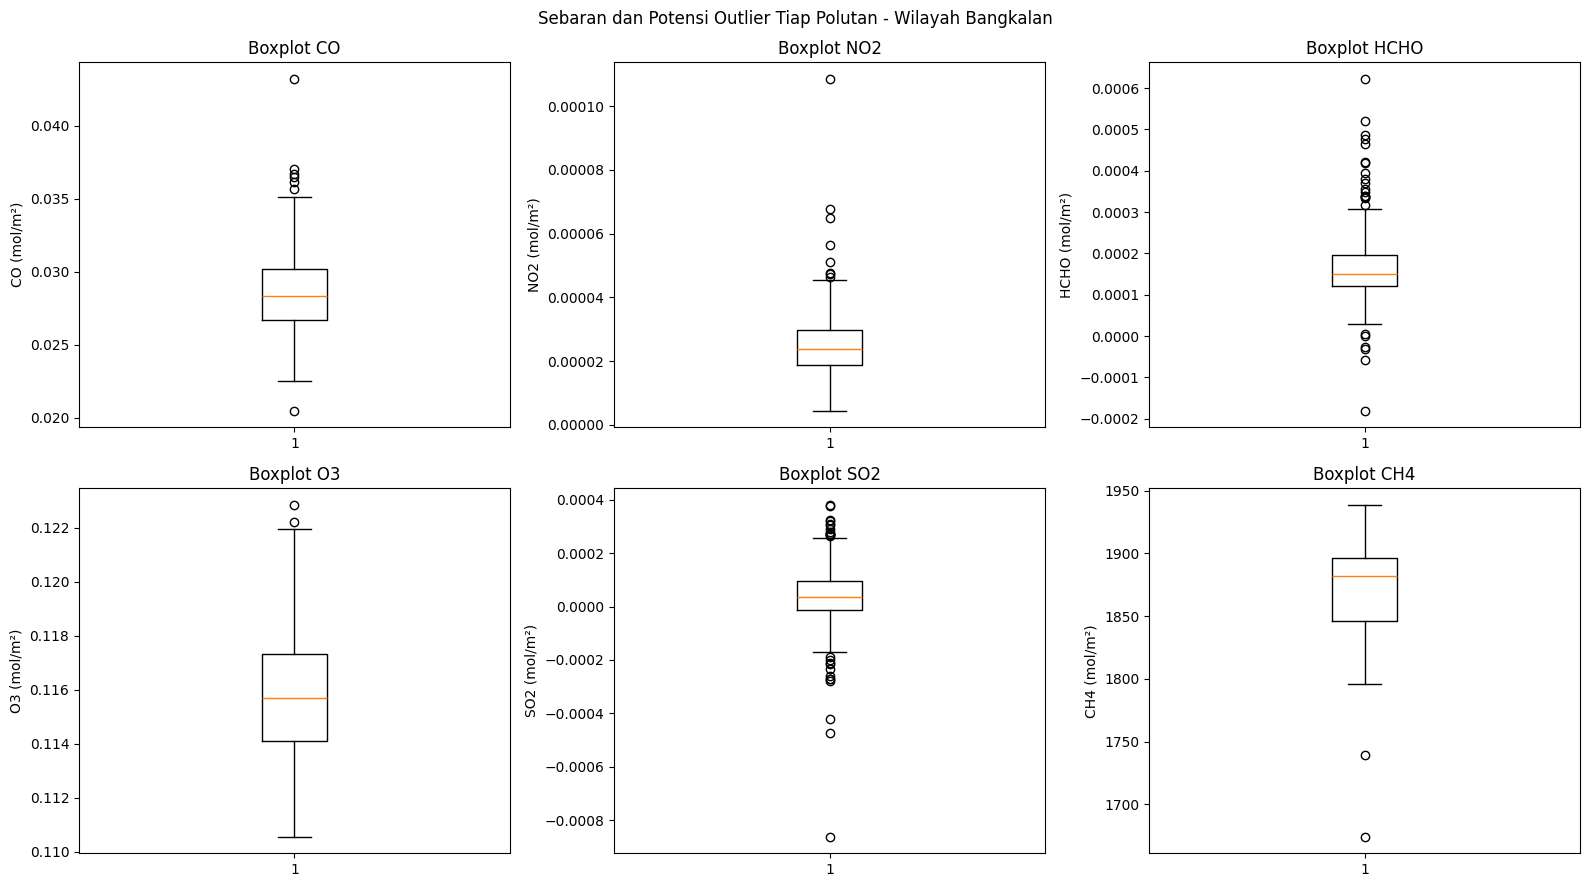

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, pol in zip(axes.flatten(), pollutants):
    ax.boxplot(
        merged_df[pol].dropna()
    )
    ax.set_title(f"Boxplot {pol}")
    ax.set_ylabel(f"{pol} (mol/m²)")

plt.suptitle(
    "Sebaran dan Potensi Outlier Tiap Polutan - Wilayah Bangkalan"
)

plt.tight_layout()
plt.show()

## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi masing-masing polutan di wilayah Kabupaten Bangkalan dari waktu ke waktu, menggunakan data harian hasil crawling (tanpa tahap pembersihan lebih lanjut, sesuai lingkup tugas ini yang berhenti pada tahap Data Understanding).

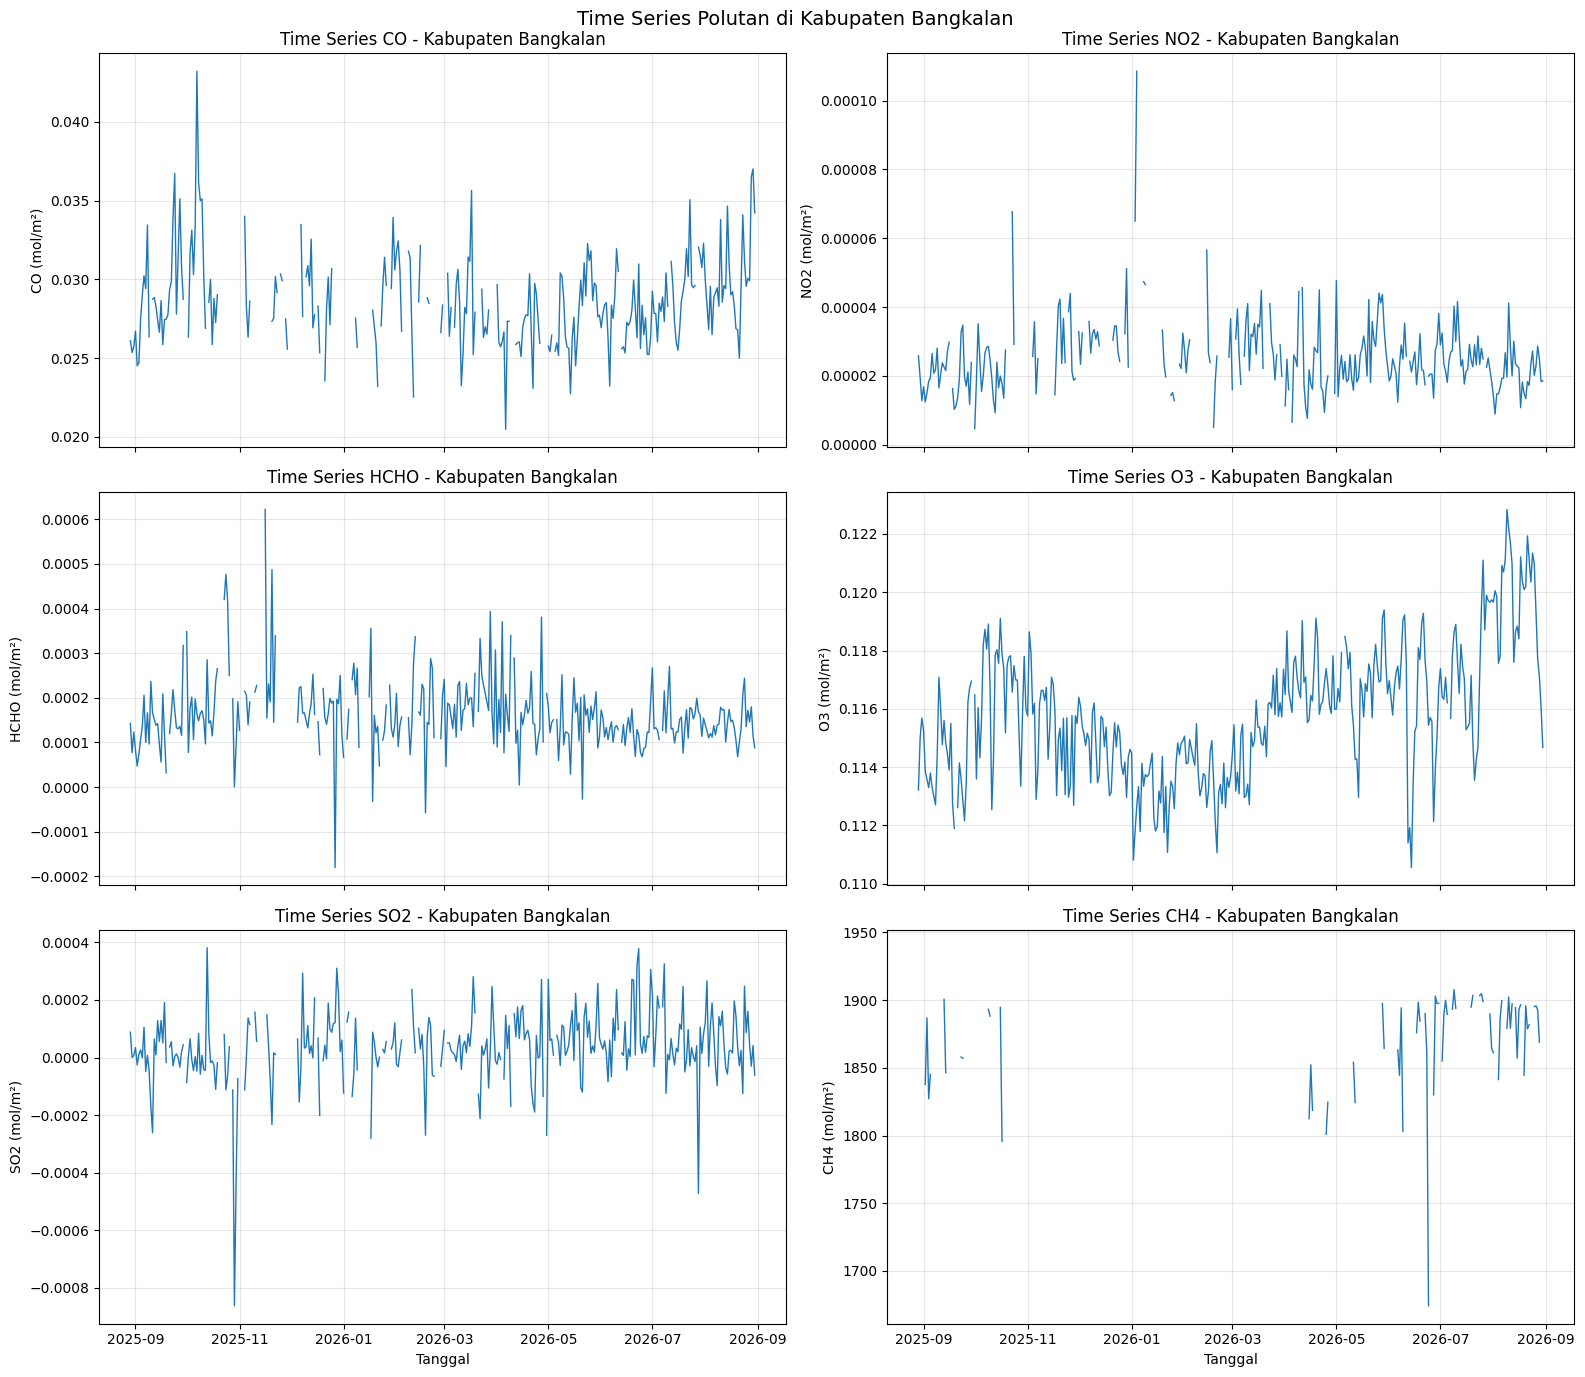

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),
    sharex=True
)

for ax, pol in zip(axes.flatten(), pollutants):
    ax.plot(
        merged_df["date"],
        merged_df[pol],
        linewidth=1
    )
    ax.set_title(
        f"Time Series {pol} - Kabupaten Bangkalan"
    )
    ax.set_ylabel(
        f"{pol} (mol/m²)"
    )
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Tanggal")
axes[-1, 1].set_xlabel("Tanggal")

plt.suptitle(
    "Time Series Polutan di Kabupaten Bangkalan",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 6. Unduh Dataset

Dataset hasil crawling polutan udara di Kabupaten Bangkalan tersedia untuk diunduh dalam format CSV. Klik tombol di bawah untuk mengunduh berkas secara langsung.


In [ ]:
# Salin CSV terbaru ke _static/ agar tersedia di HTML build
import shutil, os
csv_file = 'all_polutan_Bangkalan_timeseries.csv'
static_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), '_static')
os.makedirs(static_dir, exist_ok=True)
if os.path.exists(csv_file):
    shutil.copy2(csv_file, os.path.join(static_dir, csv_file))
    print(f'CSV disalin ke _static/')


CSV disalin ke _static/


<div style="margin:20px 0;padding:20px;
background:linear-gradient(135deg,#f0f4ff,#e8f0fe);
border-radius:12px;border-left:5px solid #4285f4;
font-family:Arial,sans-serif;">

<p style="margin:0 0 6px 0;font-weight:bold;color:#1a1a1a;font-size:15px;">
Dataset Polutan Udara - Kabupaten Bangkalan
</p>

<p style="margin:0 0 14px 0;color:#555;font-size:13px;">
Format CSV &nbsp;|&nbsp; Polutan: CO, NO2, HCHO, O3, SO2, CH4
</p>

<a href="_static/all_polutan_Bangkalan_timeseries.csv"
   download="all_polutan_Bangkalan_timeseries.csv"
   style="display:inline-block;padding:10px 24px;
   background:linear-gradient(135deg,#4285f4,#1a73e8);
   color:white;text-decoration:none;border-radius:8px;
   font-weight:bold;font-size:14px;
   box-shadow:0 2px 8px rgba(66,133,244,0.4);">
   &#11015; Download CSV
</a>

</div>


## Kesimpulan

Berdasarkan rancangan dan proses pada notebook ini, data konsentrasi enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, dan CH4) di wilayah **Kabupaten Bangkalan** akan diperoleh melalui proses crawling data satelit Sentinel-5P menggunakan pustaka OpenEO. Wilayah kajian dibatasi menggunakan GeoJSON dan data hasil crawling kemudian diolah menjadi data harian serta digabungkan ke dalam satu dataset CSV.

Enam polutan yang dianalisis meliputi **CO, NO2, HCHO, O3, SO2, dan CH4**. Proses crawling dilakukan menggunakan perulangan karena setiap permintaan data hanya mengambil satu band/polutan. Hasil setiap polutan disimpan dalam berkas NetCDF, kemudian dibaca kembali untuk memperoleh nilai rata-rata harian wilayah kajian.

Tahap **Data Understanding** mencakup pemeriksaan struktur dataset, jumlah data, missing value, statistik deskriptif, serta deteksi outlier menggunakan metode **Interquartile Range (IQR)**. Visualisasi time series digunakan untuk melihat perubahan nilai masing-masing polutan dari waktu ke waktu.

**Catatan:** angka jumlah missing value, jumlah outlier, nilai minimum/maksimum, serta pola time series pada Bangkalan harus diambil setelah notebook dijalankan kembali menggunakan data hasil crawling Bangkalan. Angka dari notebook Lamongan tidak digunakan karena tidak dapat dianggap sebagai hasil pengukuran Bangkalan.

Dengan demikian, notebook ini dapat digunakan sebagai dasar untuk melakukan crawling dan analisis awal kualitas udara di Kabupaten Bangkalan selama periode pengamatan minimal satu tahun.


# Penyimpanan Data ke PostgreSQL (Aiven) dan Penarikannya ke KNIME

## 1. Penyimpanan Data ke Basis Data (PostgreSQL — Aiven)

Selain disimpan dalam bentuk berkas CSV, data polutan yang telah diperoleh pada tahap sebelumnya juga dipindahkan ke basis data PostgreSQL yang di-hosting pada layanan Aiven. Langkah ini dilakukan agar data dapat diakses kembali secara terpusat, misalnya melalui KNIME Analytics Platform atau aplikasi lain, tanpa bergantung pada ketersediaan berkas lokal.

Seluruh kredensial koneksi (host, port, username, dan password) tidak dituliskan secara eksplisit di dalam kode, melainkan diambil melalui fitur Colab Secrets. Pendekatan ini diterapkan untuk mencegah kredensial tersebut ikut terekspos apabila notebook ini dibagikan atau diunggah ke repositori publik.


In [2]:
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("all_polutan_Bangkalan_timeseries.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("polutan_bangkalan", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "polutan_bangkalan" LIMIT 5', engine))

Berhasil! 367 baris terupload ke Aiven.
         date        CO       NO2      HCHO        O3           SO2  \
0  2025-08-29  0.026103  0.000026  0.000143  0.113214  8.791764e-05   
1  2025-08-30  0.025363  0.000020  0.000077  0.115004  8.026050e-07   
2  2025-08-31  0.025741  0.000013  0.000124  0.115688  6.201892e-06   
3  2025-09-01  0.026722  0.000017  0.000082  0.115264  3.424412e-05   
4  2025-09-02  0.024523  0.000012  0.000047  0.113861 -2.543385e-05   

           CH4  
0  1843.975260  
1          NaN  
2          NaN  
3          NaN  
4  1837.764526  


Penjelasan kode di atas adalah sebagai berikut.

- Fungsi `pd.read_csv("all_polutan_Bangkalan_timeseries.csv")` digunakan untuk membaca kembali berkas CSV yang telah dihasilkan pada tahap *Data Understanding* sebelumnya.
- Kelima variabel kredensial (`AIVEN_USER`, `AIVEN_PASSWORD`, `AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`) diperoleh melalui `userdata.get()` dari Colab Secrets, bukan dituliskan secara langsung pada kode.
- Fungsi `create_engine()` digunakan untuk membentuk koneksi ke basis data PostgreSQL Aiven melalui driver `psycopg2`, dengan parameter `sslmode=require` karena Aiven mewajibkan koneksi yang terenkripsi.
- Fungsi `df_baru.to_sql("polutan_bangkalan", engine, if_exists="replace", index=False)` mengirimkan seluruh isi dataframe ke tabel `polutan_bangkalan` pada basis data tersebut. Parameter `if_exists="replace"` berarti tabel yang sudah ada sebelumnya akan digantikan dengan data terbaru.
- Dua baris `print()` pada bagian akhir kode berfungsi sebagai verifikasi, yaitu menampilkan jumlah baris yang berhasil diunggah beserta lima baris data teratas hasil kueri dari tabel tersebut.


## 2. Menarik Data dari PostgreSQL (Aiven) ke KNIME

Setelah data polutan tersimpan pada basis data Aiven, tahap selanjutnya adalah menarik data tersebut ke KNIME Analytics Platform untuk keperluan eksplorasi lebih lanjut. Alur kerja yang digunakan tersusun atas empat node yang saling terhubung secara berurutan, yaitu **PostgreSQL Connector**, **DB Table Selector**, **DB Reader**, dan **Statistics**.

*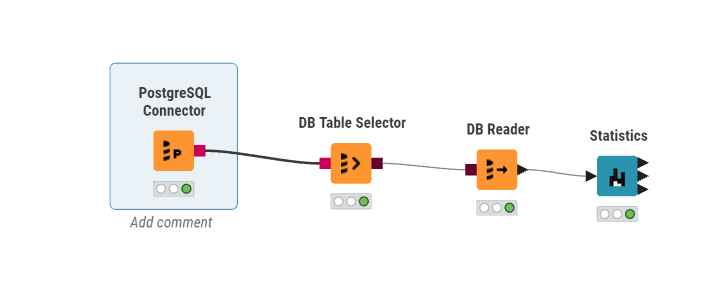*

### 2.1 PostgreSQL Connector

Berfungsi membuka koneksi ke server Aiven. Konfigurasi yang diisikan meliputi hostname sesuai `AIVEN_HOST`, port sesuai `AIVEN_PORT`, nama basis data `defaultdb`, serta username dan password sesuai kredensial Aiven, dengan SSL Mode diatur ke `require` karena Aiven mewajibkan koneksi terenkripsi. Dua port opsional pada bagian atas node dapat digunakan untuk menyuntikkan kredensial melalui flow variable; apabila tidak dihubungkan, username dan password dapat diisikan langsung pada tab konfigurasi node.

*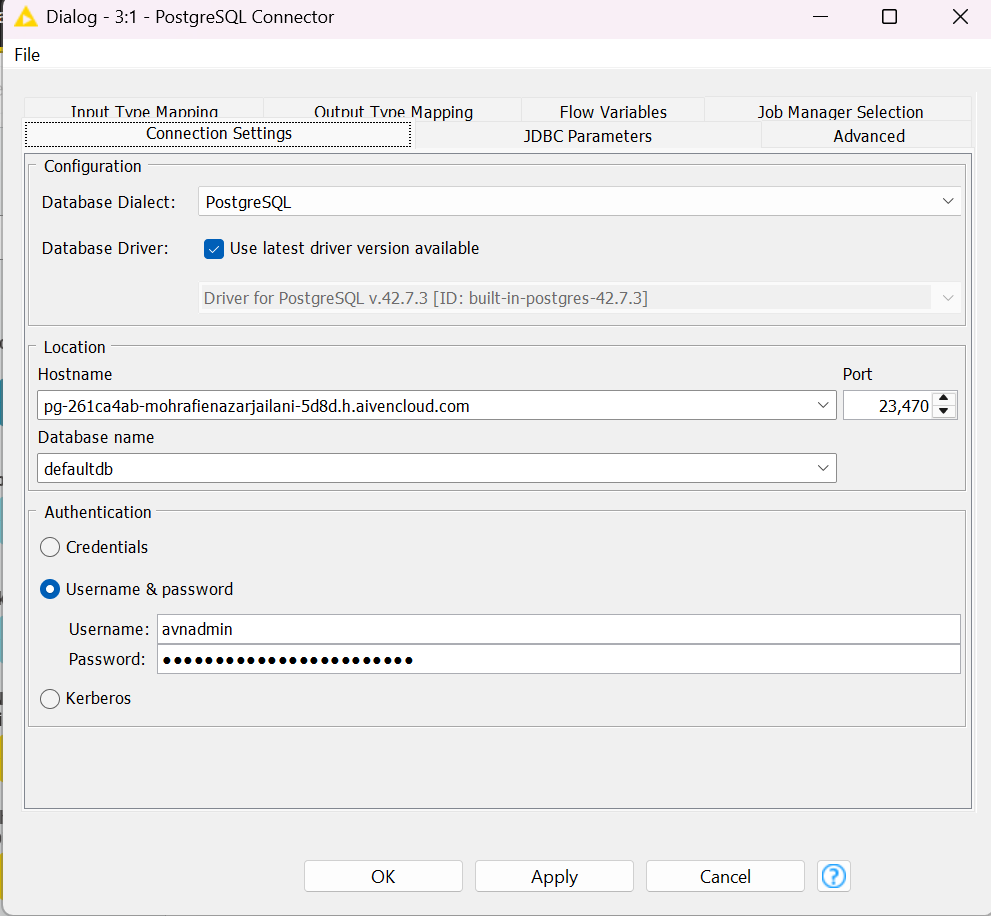*

### 2.2 DB Table Selector

Dihubungkan ke output PostgreSQL Connector, kemudian digunakan untuk memilih tabel `polutan_bangkalan` yang sebelumnya telah dibuat melalui fungsi `to_sql()`.

*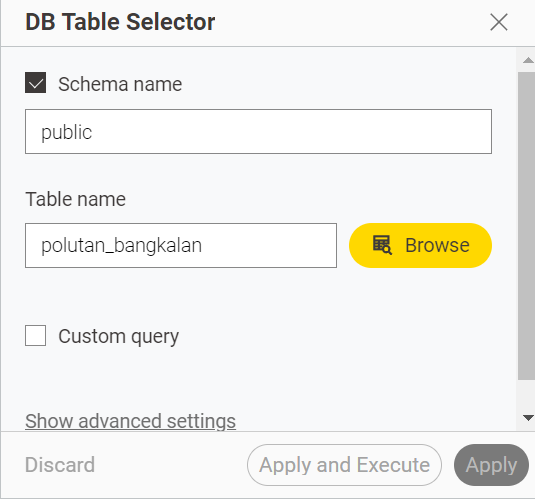*

### 2.3 DB Reader

Mengeksekusi kueri dari DB Table Selector dan mengonversi hasilnya menjadi tabel KNIME biasa, sehingga siap diproses oleh node analisis berikutnya.

*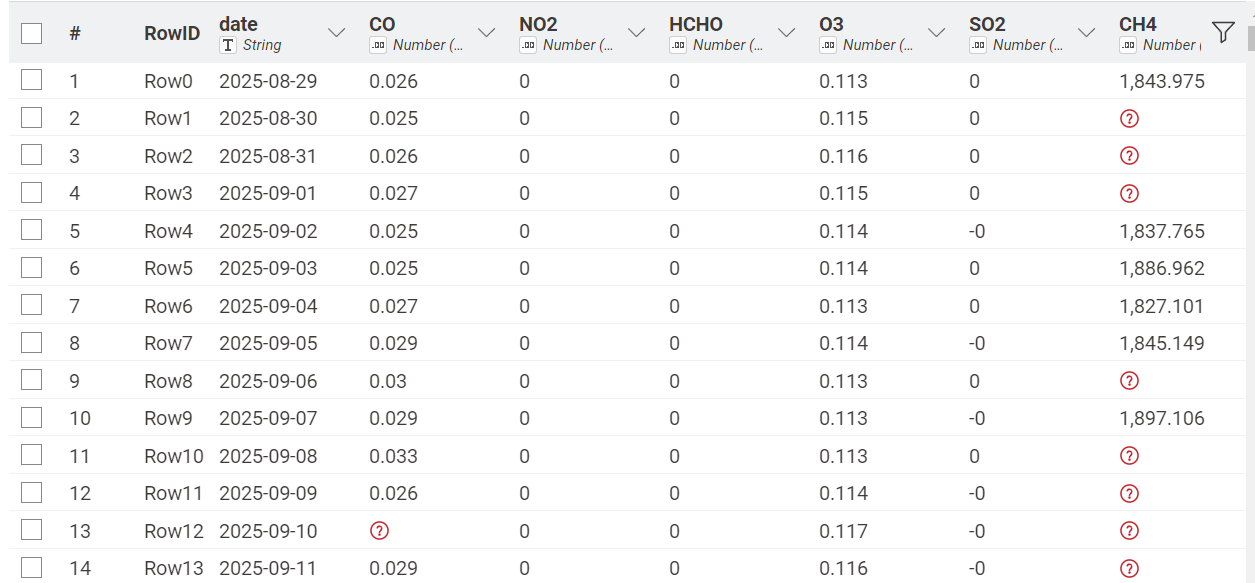*

### 2.4 Statistics

Dihubungkan langsung ke output DB Reader dan digunakan untuk menghitung ringkasan statistik (mean, median, standar deviasi, variance, min, max, kuartil, skewness, kurtosis, dan sebagainya) untuk setiap kolom polutan. Node ini memiliki tiga output port, yaitu Statistics Table, Nominal Histogram Table, dan Occurrences Table.

*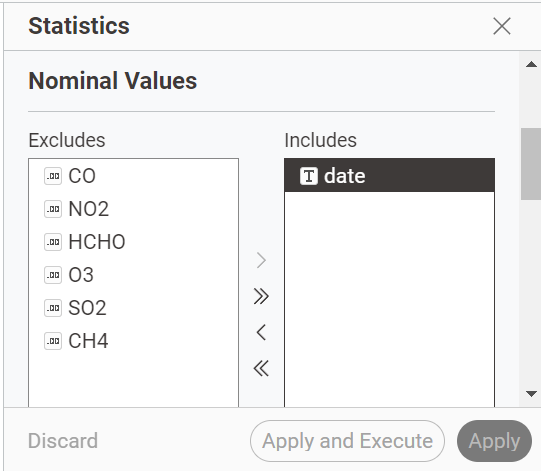*

*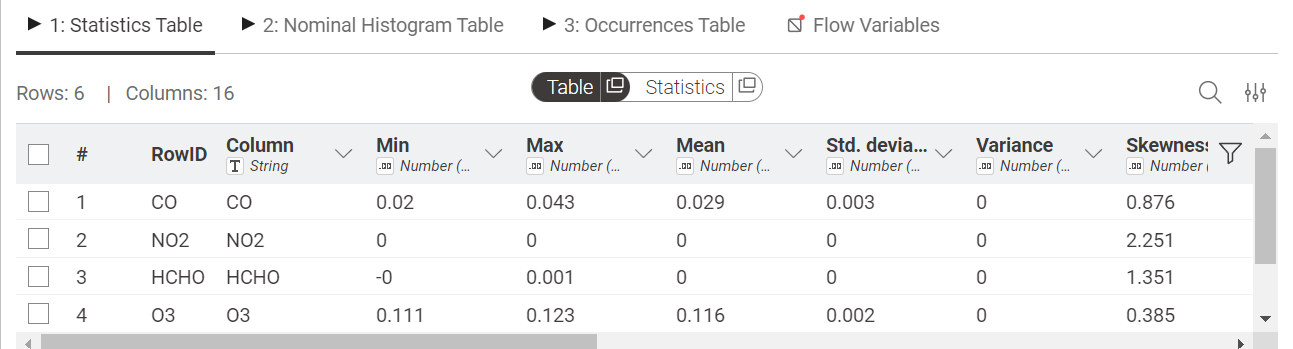*

*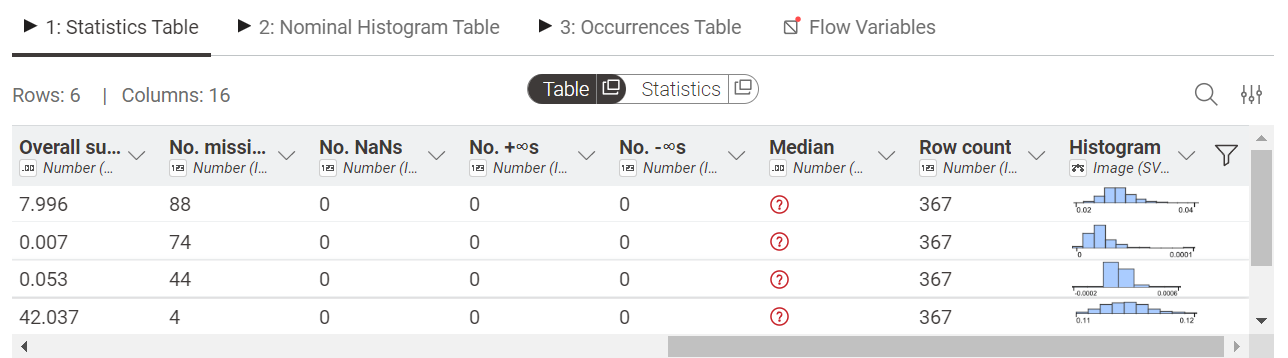*

Beberapa ukuran statistik yang dihasilkan oleh node ini meliputi:

- **Min**, yaitu nilai terkecil pada kolom.
- **Max**, yaitu nilai terbesar pada kolom.
- **Mean**, yaitu nilai rata-rata data.
- **Variance**, yaitu ukuran penyebaran data terhadap nilai rata-ratanya.
- **Std. Deviation**, yaitu akar dari variance yang lebih mudah diinterpretasikan karena memiliki satuan yang sama dengan data asli.
- **Skewness**, yaitu ukuran kemencengan (asimetri) distribusi data.
- **Kurtosis**, yaitu ukuran keruncingan distribusi data dibandingkan dengan distribusi normal.
- **Overall Sum**, yaitu jumlah seluruh nilai numerik pada kolom.
- **No. Missings**, yaitu jumlah baris yang tidak memiliki nilai pada kolom tersebut.
- **No. NaNs**, yaitu jumlah nilai yang secara eksplisit bertipe *Not a Number*.
- **No. +oos** dan **No. -oos**, yaitu jumlah nilai positif dan negatif yang berada di luar batas (*out of spec*) yang ditetapkan.
- **Median**, yaitu nilai tengah data setelah diurutkan.
- **Row Count**, yaitu jumlah seluruh baris tabel, termasuk baris yang bernilai *missing*. Perlu digarisbawahi bahwa Row Count berbeda dengan jumlah data yang benar-benar digunakan dalam perhitungan Mean, Variance, dan statistik numerik lainnya, karena nilai *missing* tidak diikutsertakan dalam perhitungan tersebut.


## 3. Ilustrasi Perhitungan Statistik

Sebagai ilustrasi cara kerja node Statistics, diambil data kolom **CO** pada lima baris pertama data Bangkalan:

| Hari | Tanggal | CO |
|---|---|---|
| 1 | 2025-08-29 | 0,026103 |
| 2 | 2025-08-30 | 0,025363 |
| 3 | 2025-08-31 | 0,025741 |
| 4 | 2025-09-01 | 0,026722 |
| 5 | 2025-09-02 | 0,024523 |

Seluruh nilai CO pada lima baris pertama ini tercatat lengkap (tidak ada yang kosong), sehingga banyaknya data yang dipakai dalam perhitungan berikut adalah $n = 5$.

### 3.1 Min

Min adalah nilai paling kecil di antara seluruh data yang tersedia.

$$\text{Min} = \min(x_1, x_2, \dots, x_n)$$

$$\text{Min} = \min(0{,}026103;\ 0{,}025363;\ 0{,}025741;\ 0{,}026722;\ 0{,}024523) = 0{,}024523$$

Sehingga Min CO = 0,024523.

### 3.2 Max

Kebalikan dari Min, Max adalah nilai paling besar di antara data yang ada.

$$\text{Max} = \max(x_1, x_2, \dots, x_n)$$

$$\text{Max} = \max(0{,}026103;\ 0{,}025363;\ 0{,}025741;\ 0{,}026722;\ 0{,}024523) = 0{,}026722$$

Sehingga Max CO = 0,026722.

### 3.3 Mean

Mean merupakan nilai rata-rata dari seluruh data numerik yang tersedia.

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

$$\bar{x} = \frac{0{,}026103 + 0{,}025363 + 0{,}025741 + 0{,}026722 + 0{,}024523}{5} = \frac{0{,}128452}{5} = 0{,}0256904$$

Sehingga Mean CO = 0,0256904.

### 3.4 Variance

Variance menunjukkan besarnya penyebaran data terhadap nilai rata-ratanya. Pada contoh ini digunakan rumus *sample variance*:

$$s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

Dengan $\bar{x} = 0{,}0256904$, selisih tiap nilai terhadap mean beserta kuadratnya adalah sebagai berikut:

| $x_i$ | $x_i - \bar{x}$ | $(x_i-\bar{x})^2$ |
|---|---|---|
| 0,026103 | 0,0004126 | 0,00000017 |
| 0,025363 | -0,0003273 | 0,00000011 |
| 0,025741 | 0,0000506 | 0,00000000 |
| 0,026722 | 0,0010317 | 0,00000106 |
| 0,024523 | -0,0011676 | 0,00000136 |

Jumlah seluruh kuadrat selisih tersebut $\approx 0{,}0000027076$, sehingga:

$$s^2 = \frac{0{,}0000027076}{5-1} \approx 0{,}0000006769$$

Diperoleh Variance CO ≈ 0,0000006769.

### 3.5 Std. Deviation

Standar deviasi merupakan akar dari variance, dan lebih mudah diinterpretasikan karena satuannya sama dengan data aslinya.

$$s = \sqrt{s^2} = \sqrt{0{,}0000006769} \approx 0{,}0008227$$

Diperoleh Std. Deviation CO ≈ 0,0008227.

### 3.6 Skewness

Skewness mengukur tingkat kemencengan (asimetri) distribusi data, menggunakan rumus *corrected sample skewness*:

$$G_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$

Dengan $n = 5$, $\bar{x} = 0{,}0256904$, dan $s \approx 0{,}0008227$, diperoleh:

$$G_1 \approx -0{,}3431$$

Nilai Skewness CO ≈ -0,3431 ini bertanda negatif, menandakan distribusi data pada lima baris ini sedikit condong ke arah kiri (didominasi nilai yang berkumpul di sekitar mean dengan satu nilai terendah di baris kelima yang menarik ekor distribusi ke kiri).

### 3.7 Kurtosis

Kurtosis menggambarkan tingkat keruncingan distribusi dibandingkan distribusi normal, dihitung dengan rumus *corrected sample excess kurtosis*:

$$G_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

Dengan $n = 5$, hasil perhitungannya:

$$G_2 \approx 0{,}2717$$

Nilai Kurtosis CO ≈ 0,2717 yang mendekati 0 ini mengindikasikan bahwa distribusi data pada lima baris ini cukup mendekati bentuk distribusi normal, tidak terlalu runcing maupun terlalu tumpul.

### 3.8 Overall Sum

Overall Sum adalah total penjumlahan seluruh nilai numerik yang tersedia pada kolom tersebut.

$$\text{Sum} = \sum_{i=1}^{n} x_i$$

$$\text{Sum} = 0{,}026103 + 0{,}025363 + 0{,}025741 + 0{,}026722 + 0{,}024523 = 0{,}128452$$

Sehingga Overall Sum CO = 0,128452.

### 3.9 No. Missings

Fitur ini mencatat jumlah baris yang tidak memiliki nilai (kosong) pada kolom tersebut. Karena pada lima baris pertama ini seluruh data CO terisi lengkap:

$$\text{No. Missings} = 0$$

### 3.10 No. NaNs

Berbeda dari missing value, No. NaNs khusus menghitung nilai yang secara eksplisit bertipe *Not a Number*. Pada contoh ini juga tidak ditemukan nilai semacam itu:

$$\text{No. NaNs} = 0$$

### 3.11 No. +oos

Fitur ini menunjukkan banyaknya nilai positif yang berada di luar batas (*out of spec*) yang ditetapkan. Tidak ada data pada contoh ini yang termasuk kategori tersebut:

$$\text{No. } {+oos} = 0$$

### 3.12 No. -oos

Sebaliknya, fitur ini menghitung nilai negatif yang berada di luar batas yang ditetapkan. Pada contoh ini juga tidak ditemukan data semacam itu:

$$\text{No. } {-oos} = 0$$

### 3.13 Median

Median merupakan nilai yang berada tepat di tengah setelah data diurutkan. Data yang telah diurutkan:

$$0{,}024523;\ 0{,}025363;\ 0{,}025741;\ 0{,}026103;\ 0{,}026722$$

Karena jumlah data ganjil ($n = 5$), median diambil langsung dari nilai tengah (data ke-3):

$$\text{Median} = x_{(3)} = 0{,}025741$$

Sehingga Median CO = 0,025741.

### 3.14 Row Count

Row Count menghitung seluruh baris pada tabel, termasuk yang bernilai missing. Pada contoh ini terdapat 5 baris:

$$\text{Row Count} = 5$$

Perlu digarisbawahi bahwa Row Count tidak selalu sama dengan jumlah data yang dipakai dalam perhitungan Mean, Variance, dan statistik numerik lainnya — pada contoh ini kebetulan sama karena tidak ada nilai yang kosong, namun akan berbeda bila salah satu barisnya missing (seperti pada kolom CH4, yang sebagian besar datanya belum tersedia sepanjang periode pengamatan).


## Kesimpulan

Data polutan yang telah tersimpan sebagai CSV diunggah ke basis data PostgreSQL (Aiven), dengan kredensial disimpan lewat Colab Secrets agar tidak ikut terekspos. Data tersebut kemudian ditarik ke KNIME melalui alur empat node — PostgreSQL Connector, DB Table Selector, DB Reader, dan Statistics — untuk menghasilkan ringkasan statistik tiap polutan secara otomatis. Hasilnya sejalan dengan perhitungan manual pada bagian sebelumnya, sehingga proses penyimpanan dan penarikan data antara Aiven dan KNIME dapat dipastikan berjalan dengan benar.
